In [1]:
# =============================================================================
# NEURAL FEATURE EXTRACTION CONFIGURATION
# =============================================================================

# Basic trial and timing parameters
TRIAL_NUMBER = 2  # Trial to analyze
TIME_BIN_SIZE = 0.02  # seconds (20 ms bins for feature extraction)
SAMPLING_RATE = 30000  # Hz (neural data sampling rate)

# Display options
SHOW_N_CHANNELS = 21  # Number of channels to display in plots
FIGURE_SIZE = (15, 10)  # Figure size for plots

# Spike channels (manually identified)
SPIKE_CHANNELS = [0, 1, 2, 3, 6, 32, 39, 40, 41, 42, 46, 49, 53, 67, 68, 73, 74, 75, 76, 77, 84]

# =============================================================================
# FILTERING PARAMETERS
# =============================================================================

# Spike band filtering (high-frequency activity)
SPIKE_BAND_LOW = 400    # Hz - Lower cutoff for spike band
SPIKE_BAND_HIGH = 6000  # Hz - Upper cutoff for spike band
SPIKE_FILTER_ORDER = 4  # Butterworth filter order

# LFP filtering (low-frequency activity)
LFP_CUTOFF = 250        # Hz - Low-pass cutoff for LFP
LFP_FILTER_ORDER = 4    # Butterworth filter order

# Gamma band filtering
GAMMA_LOW = 30          # Hz - Lower cutoff for gamma band
GAMMA_HIGH = 100        # Hz - Upper cutoff for gamma band
GAMMA_FILTER_ORDER = 4  # Butterworth filter order

# =============================================================================
# THRESHOLD CROSSING PARAMETERS (SPIKE DETECTION)
# =============================================================================

# Threshold crossing detection
THRESHOLD_METHOD = 'rms'        # Method: 'rms', 'std', 'median', 'manual'
THRESHOLD_MULTIPLIER = -4.0     # Threshold multiplier (negative for negative-going spikes)
THRESHOLD_POLARITY = 'negative' # Spike polarity: 'negative', 'positive', 'both'

# Alternative threshold methods
MANUAL_THRESHOLD = -50.0        # Manual threshold in microvolts (if method='manual')
MEDIAN_MULTIPLIER = 4.0         # Multiplier for median-based threshold
STD_MULTIPLIER = 3.0            # Multiplier for standard deviation-based threshold

# Spike detection refinement
MIN_SPIKE_INTERVAL = 0.001      # Minimum interval between spikes (1 ms refractory period)
SPIKE_WINDOW_PRE = 0.0005       # Pre-spike window (0.5 ms)
SPIKE_WINDOW_POST = 0.001       # Post-spike window (1 ms)

# =============================================================================
# FEATURE EXTRACTION PARAMETERS
# =============================================================================

# Power spectral density
PSD_WINDOW = 'hann'            # Window function for PSD
PSD_OVERLAP = 0.5              # Overlap fraction for PSD
PSD_NFFT = 1024                # FFT length for PSD

# Moving window parameters
MOVING_WINDOW_SIZE = 0.01      # seconds (10 ms moving window)
MOVING_WINDOW_OVERLAP = 0.5    # Overlap fraction for moving windows

# Voltage-based features
VOLTAGE_PERCENTILES = [10, 25, 50, 75, 90]  # Percentiles to calculate
CALCULATE_KURTOSIS = True      # Calculate signal kurtosis
CALCULATE_SKEWNESS = True      # Calculate signal skewness

# =============================================================================
# ARTIFACT DETECTION PARAMETERS
# =============================================================================

# Artifact detection thresholds
ARTIFACT_VOLTAGE_THRESHOLD = 500   # microvolts - extreme voltage threshold
ARTIFACT_GRADIENT_THRESHOLD = 100  # microvolts/sample - rapid change threshold
ARTIFACT_FREQUENCY_THRESHOLD = 0.1 # Fraction of time in artifact state

# Saturation detection
SATURATION_THRESHOLD = 0.95        # Fraction of max range for saturation detection
SATURATION_DURATION = 0.001        # Minimum duration (1 ms) to consider saturation

# =============================================================================
# ADVANCED FEATURE PARAMETERS
# =============================================================================

# Spectral edge frequency
SPECTRAL_EDGE_FRACTION = 0.95      # Fraction of power for spectral edge

# Coherence analysis
COHERENCE_FREQ_BANDS = {
    'delta': (1, 4),
    'theta': (4, 8),
    'alpha': (8, 12),
    'beta': (12, 30),
    'gamma': (30, 100)
}

# Burst detection
BURST_THRESHOLD = 2.0              # Threshold for burst detection (x baseline)
BURST_MIN_DURATION = 0.05          # Minimum burst duration (50 ms)
BURST_MAX_INTERVAL = 0.01          # Maximum interval within burst (10 ms)

# =============================================================================
# FEATURE SELECTION
# =============================================================================

# Enable/disable specific features
EXTRACT_SPIKE_BAND = True          # Extract spike band power
EXTRACT_LFP = True                 # Extract LFP features
EXTRACT_GAMMA = True               # Extract gamma band power
EXTRACT_THRESHOLD_CROSSINGS = True # Extract threshold crossings
EXTRACT_VOLTAGE_FEATURES = True    # Extract voltage-based features
EXTRACT_SPECTRAL_FEATURES = True   # Extract spectral features
EXTRACT_BURST_FEATURES = True      # Extract burst detection features
EXTRACT_ARTIFACT_FEATURES = True   # Extract artifact detection features

# =============================================================================
# VALIDATION AND SUMMARY
# =============================================================================

print("🎛️  NEURAL FEATURE EXTRACTION CONFIGURATION")
print("="*60)
print(f"📊 Basic Parameters:")
print(f"   • Trial: {TRIAL_NUMBER}")
print(f"   • Time bin size: {TIME_BIN_SIZE*1000:.0f} ms")
print(f"   • Sampling rate: {SAMPLING_RATE} Hz")
print(f"   • Channels: {len(SPIKE_CHANNELS)} spike channels")

print(f"\n🔧 Filtering:")
print(f"   • Spike band: {SPIKE_BAND_LOW}-{SPIKE_BAND_HIGH} Hz")
print(f"   • LFP cutoff: {LFP_CUTOFF} Hz")
print(f"   • Gamma band: {GAMMA_LOW}-{GAMMA_HIGH} Hz")

print(f"\n⚡ Threshold Crossing (Spike Detection):")
print(f"   • Method: {THRESHOLD_METHOD}")
print(f"   • Multiplier: {THRESHOLD_MULTIPLIER}x")
print(f"   • Polarity: {THRESHOLD_POLARITY}")
print(f"   • Refractory period: {MIN_SPIKE_INTERVAL*1000:.1f} ms")

print(f"\n🎯 Feature Selection:")
enabled_features = []
if EXTRACT_SPIKE_BAND: enabled_features.append("Spike Band")
if EXTRACT_LFP: enabled_features.append("LFP")
if EXTRACT_GAMMA: enabled_features.append("Gamma")
if EXTRACT_THRESHOLD_CROSSINGS: enabled_features.append("Threshold Crossings")
if EXTRACT_VOLTAGE_FEATURES: enabled_features.append("Voltage Stats")
if EXTRACT_SPECTRAL_FEATURES: enabled_features.append("Spectral")
if EXTRACT_BURST_FEATURES: enabled_features.append("Burst Detection")
if EXTRACT_ARTIFACT_FEATURES: enabled_features.append("Artifact Detection")

print(f"   • Enabled: {', '.join(enabled_features)}")

print(f"\n📏 Display:")
print(f"   • Show channels: {SHOW_N_CHANNELS}")
print(f"   • Figure size: {FIGURE_SIZE}")

print(f"\n💡 Tips:")
print(f"   • Adjust THRESHOLD_MULTIPLIER (-2 to -6) for spike sensitivity")
print(f"   • Use TIME_BIN_SIZE 10-50ms for different temporal resolution")
print(f"   • Enable/disable features to focus on specific analyses")
print("="*60)

🎛️  NEURAL FEATURE EXTRACTION CONFIGURATION
📊 Basic Parameters:
   • Trial: 2
   • Time bin size: 20 ms
   • Sampling rate: 30000 Hz
   • Channels: 21 spike channels

🔧 Filtering:
   • Spike band: 400-6000 Hz
   • LFP cutoff: 250 Hz
   • Gamma band: 30-100 Hz

⚡ Threshold Crossing (Spike Detection):
   • Method: rms
   • Multiplier: -4.0x
   • Polarity: negative
   • Refractory period: 1.0 ms

🎯 Feature Selection:
   • Enabled: Spike Band, LFP, Gamma, Threshold Crossings, Voltage Stats, Spectral, Burst Detection, Artifact Detection

📏 Display:
   • Show channels: 21
   • Figure size: (15, 10)

💡 Tips:
   • Adjust THRESHOLD_MULTIPLIER (-2 to -6) for spike sensitivity
   • Use TIME_BIN_SIZE 10-50ms for different temporal resolution
   • Enable/disable features to focus on specific analyses


In [2]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from neural_feature_extraction import NeuralFeatureExtractor, find_h5_file
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

print("✅ Setup complete!")


✅ Setup complete!


In [3]:
def load_and_extract_features(trial_number=TRIAL_NUMBER, time_bin_size=TIME_BIN_SIZE):
    """Load trial data and extract all neural features."""
    # Find H5 file
    h5_file = find_h5_file()
    if h5_file is None:
        print("❌ No H5 files found!")
        return None, None
    
    print(f"📁 Using H5 file: {h5_file}")
    
    # Initialize extractor
    extractor = NeuralFeatureExtractor(sampling_rate=30000)
    
    # Load trial data
    print(f"📂 Loading trial {trial_number}...")
    trial_data = extractor.load_trial_data(h5_file, trial_number)
    
    # Extract features
    print(f"🔍 Extracting features for {len(SPIKE_CHANNELS)} channels...")
    features = extractor.extract_all_features(
        trial_data['neural_data'], 
        SPIKE_CHANNELS, 
        time_bin_size
    )
    
    print("✅ Feature extraction complete!")
    return trial_data, features

# Load data
trial_data, features = load_and_extract_features()

if features is not None:
    print(f"\n📊 Data loaded successfully:")
    print(f"  • Neural data shape: {trial_data['neural_data'].shape}")
    print(f"  • Selected channels: {len(SPIKE_CHANNELS)}")
    print(f"  • Time bins: {len(features['spike_band']['time_axis'])}")
    print(f"  • Bin size: {TIME_BIN_SIZE*1000:.0f} ms")


📁 Using H5 file: D:\Data\ScienceCorp\trials_aligned.h5
📂 Loading trial 2...
🔍 Extracting features for 21 channels...
🚀 Extracting features for 21 channels...
📊 Data shape: (21, 87168)
⏱️  Time bin size: 50 ms
🔍 Extracting spike band power (400-6000 Hz)...
✅ Spike band power extraction completed
🧠 Extracting LFP features (low-pass <250 Hz, gamma 30-100 Hz)...
✅ LFP feature extraction completed
⚡ Extracting voltage features (moving average and variance)...
✅ Voltage feature extraction completed
🎯 Extracting threshold crossings (-4x RMS)...
✅ Threshold crossing extraction completed
✅ Feature extraction complete!

📊 Data loaded successfully:
  • Neural data shape: (96, 87168)
  • Selected channels: 21
  • Time bins: 145
  • Bin size: 20 ms


In [4]:
def show_feature_summary(features):
    """Display a summary of all extracted features."""
    if features is None:
        print("❌ No features to display")
        return
    
    print("="*60)
    print("NEURAL FEATURE SUMMARY")
    print("="*60)
    
    # Get feature data
    spike_rms = features['spike_band']['rms_power']
    lfp_power = features['lfp']['lfp_power']
    gamma_power = features['lfp']['gamma_power']
    crossings = features['threshold']['crossing_counts']
    
    # Calculate statistics
    print(f"📊 Feature Statistics:")
    print(f"  • Spike RMS Power: {np.mean(spike_rms):.3f} ± {np.std(spike_rms):.3f}")
    print(f"  • LFP Power: {np.mean(lfp_power):.3f} ± {np.std(lfp_power):.3f}")
    print(f"  • Gamma Power: {np.mean(gamma_power):.3f} ± {np.std(gamma_power):.3f}")
    print(f"  • Total Crossings: {np.sum(crossings):.0f}")
    
    # Find most active channels
    spike_mean = np.mean(spike_rms, axis=1)
    crossing_sum = np.sum(crossings, axis=1)
    activity_score = spike_mean + crossing_sum/np.max(crossing_sum)*np.max(spike_mean)
    top_channels = np.argsort(activity_score)[-5:][::-1]
    
    print(f"\n🔥 Most active channels: {[SPIKE_CHANNELS[i] for i in top_channels]}")
    
    # Channel-wise statistics
    print(f"\n📈 Channel Statistics:")
    for i, ch in enumerate(SPIKE_CHANNELS[:5]):  # Show first 5 channels
        print(f"  • Channel {ch:2d}: Spike={spike_mean[i]:.3f}, Crossings={crossing_sum[i]:.0f}")

show_feature_summary(features)


NEURAL FEATURE SUMMARY
📊 Feature Statistics:
  • Spike RMS Power: 25.559 ± 9.265
  • LFP Power: 15355.684 ± 19534.470
  • Gamma Power: 1072.460 ± 1258.361
  • Total Crossings: 13521

🔥 Most active channels: [39, 1, 40, 49, 46]

📈 Channel Statistics:
  • Channel  0: Spike=21.757, Crossings=481
  • Channel  1: Spike=29.552, Crossings=2355
  • Channel  2: Spike=25.105, Crossings=495
  • Channel  3: Spike=28.500, Crossings=298
  • Channel  6: Spike=22.134, Crossings=6


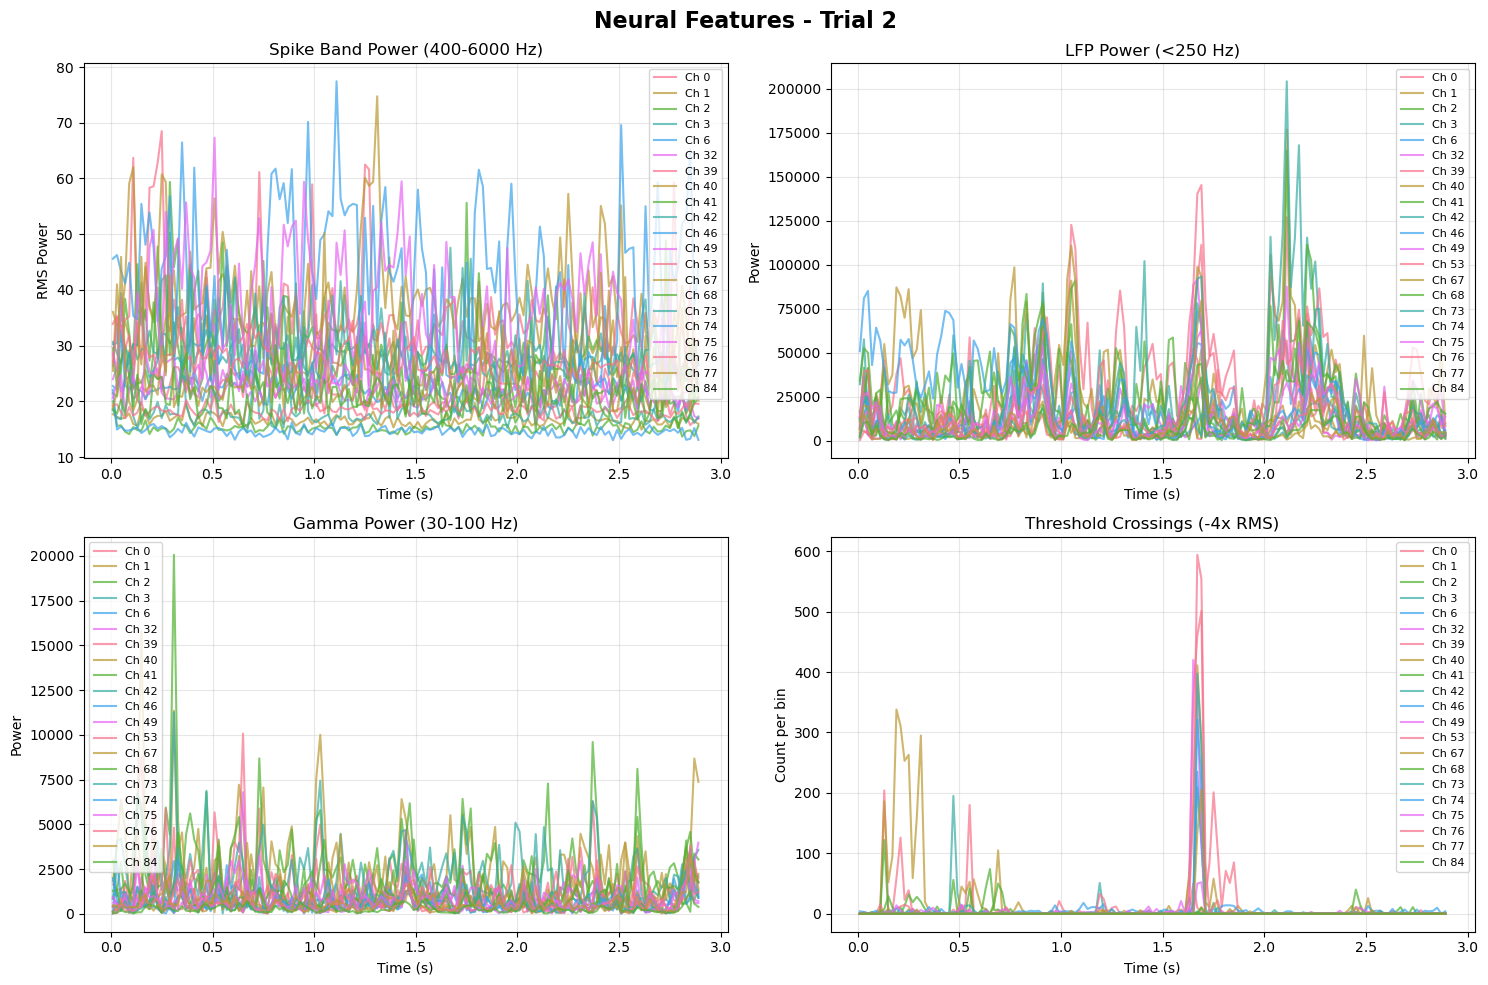

In [5]:
def quick_plot_features(features, n_channels=SHOW_N_CHANNELS, figsize=FIGURE_SIZE):
    """Create a quick visualization of the main features."""
    if features is None:
        print("❌ No features to plot")
        return
    
    # Get data
    time_axis = features['spike_band']['time_axis']
    spike_rms = features['spike_band']['rms_power']
    lfp_power = features['lfp']['lfp_power']
    gamma_power = features['lfp']['gamma_power']
    crossings = features['threshold']['crossing_counts']
    
    # Create figure
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    fig.suptitle(f'Neural Features - Trial {TRIAL_NUMBER}', fontsize=16, fontweight='bold')
    
    # Plot 1: Spike Band Power
    ax1 = axes[0, 0]
    for i in range(min(n_channels, len(SPIKE_CHANNELS))):
        ax1.plot(time_axis, spike_rms[i], label=f'Ch {SPIKE_CHANNELS[i]}', alpha=0.7)
    ax1.set_title('Spike Band Power (400-6000 Hz)')
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('RMS Power')
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: LFP Power
    ax2 = axes[0, 1]
    for i in range(min(n_channels, len(SPIKE_CHANNELS))):
        ax2.plot(time_axis, lfp_power[i], label=f'Ch {SPIKE_CHANNELS[i]}', alpha=0.7)
    ax2.set_title('LFP Power (<250 Hz)')
    ax2.set_xlabel('Time (s)')
    ax2.set_ylabel('Power')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Gamma Power
    ax3 = axes[1, 0]
    for i in range(min(n_channels, len(SPIKE_CHANNELS))):
        ax3.plot(time_axis, gamma_power[i], label=f'Ch {SPIKE_CHANNELS[i]}', alpha=0.7)
    ax3.set_title('Gamma Power (30-100 Hz)')
    ax3.set_xlabel('Time (s)')
    ax3.set_ylabel('Power')
    ax3.legend(fontsize=8)
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: Threshold Crossings
    ax4 = axes[1, 1]
    for i in range(min(n_channels, len(SPIKE_CHANNELS))):
        ax4.plot(time_axis, crossings[i], label=f'Ch {SPIKE_CHANNELS[i]}', alpha=0.7)
    ax4.set_title('Threshold Crossings (-4x RMS)')
    ax4.set_xlabel('Time (s)')
    ax4.set_ylabel('Count per bin')
    ax4.legend(fontsize=8)
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

quick_plot_features(features)


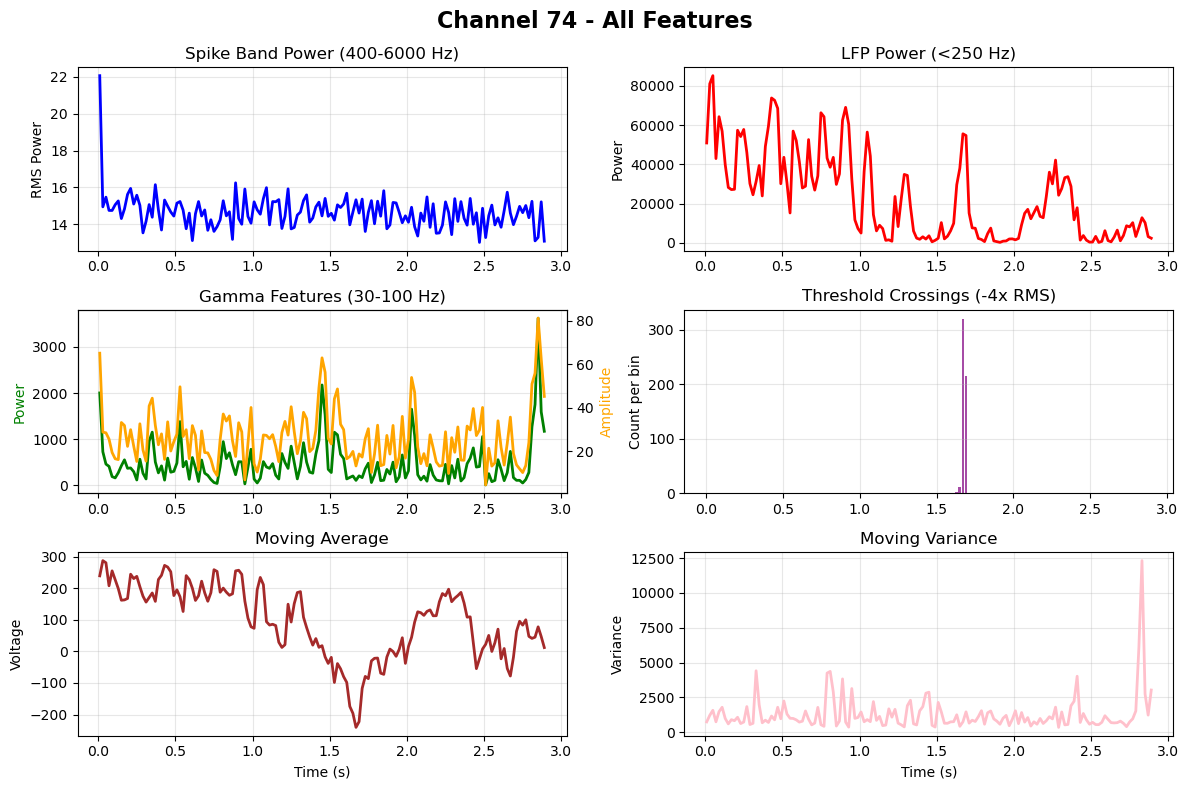


📊 Channel 74 Statistics:
  • Spike RMS Power: 14.663 ± 0.940
  • LFP Power: 23231.277 ± 21823.092
  • Gamma Power: 471.757 ± 479.407
  • Total Crossings: 550
  • Moving Average: 96.340 ± 113.956
  • Moving Variance: 1297.285 ± 1296.948


In [6]:
def explore_channel(features, channel_number, figsize=(12, 8)):
    """Explore all features for a specific channel."""
    if features is None:
        print("❌ No features to explore")
        return
    
    # Find channel index
    try:
        ch_idx = SPIKE_CHANNELS.index(channel_number)
    except ValueError:
        print(f"❌ Channel {channel_number} not in spike channels list")
        return
    
    # Get data
    time_axis = features['spike_band']['time_axis']
    spike_rms = features['spike_band']['rms_power'][ch_idx]
    lfp_power = features['lfp']['lfp_power'][ch_idx]
    gamma_power = features['lfp']['gamma_power'][ch_idx]
    gamma_amp = features['lfp']['gamma_amplitude'][ch_idx]
    crossings = features['threshold']['crossing_counts'][ch_idx]
    mov_avg = features['voltage']['moving_average'][ch_idx]
    mov_var = features['voltage']['moving_variance'][ch_idx]
    
    # Create figure
    fig, axes = plt.subplots(3, 2, figsize=figsize)
    fig.suptitle(f'Channel {channel_number} - All Features', fontsize=16, fontweight='bold')
    
    # Spike band power
    axes[0, 0].plot(time_axis, spike_rms, 'b-', linewidth=2)
    axes[0, 0].set_title('Spike Band Power (400-6000 Hz)')
    axes[0, 0].set_ylabel('RMS Power')
    axes[0, 0].grid(True, alpha=0.3)
    
    # LFP power
    axes[0, 1].plot(time_axis, lfp_power, 'r-', linewidth=2)
    axes[0, 1].set_title('LFP Power (<250 Hz)')
    axes[0, 1].set_ylabel('Power')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Gamma power and amplitude
    ax1 = axes[1, 0]
    ax1.plot(time_axis, gamma_power, 'g-', linewidth=2, label='Gamma Power')
    ax2 = ax1.twinx()
    ax2.plot(time_axis, gamma_amp, 'orange', linewidth=2, label='Gamma Amplitude')
    ax1.set_title('Gamma Features (30-100 Hz)')
    ax1.set_ylabel('Power', color='g')
    ax2.set_ylabel('Amplitude', color='orange')
    ax1.grid(True, alpha=0.3)
    
    # Threshold crossings
    axes[1, 1].bar(time_axis, crossings, width=TIME_BIN_SIZE*0.8, alpha=0.7, color='purple')
    axes[1, 1].set_title('Threshold Crossings (-4x RMS)')
    axes[1, 1].set_ylabel('Count per bin')
    axes[1, 1].grid(True, alpha=0.3)
    
    # Moving average
    axes[2, 0].plot(time_axis, mov_avg, 'brown', linewidth=2)
    axes[2, 0].set_title('Moving Average')
    axes[2, 0].set_xlabel('Time (s)')
    axes[2, 0].set_ylabel('Voltage')
    axes[2, 0].grid(True, alpha=0.3)
    
    # Moving variance
    axes[2, 1].plot(time_axis, mov_var, 'pink', linewidth=2)
    axes[2, 1].set_title('Moving Variance')
    axes[2, 1].set_xlabel('Time (s)')
    axes[2, 1].set_ylabel('Variance')
    axes[2, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print channel statistics
    print(f"\n📊 Channel {channel_number} Statistics:")
    print(f"  • Spike RMS Power: {np.mean(spike_rms):.3f} ± {np.std(spike_rms):.3f}")
    print(f"  • LFP Power: {np.mean(lfp_power):.3f} ± {np.std(lfp_power):.3f}")
    print(f"  • Gamma Power: {np.mean(gamma_power):.3f} ± {np.std(gamma_power):.3f}")
    print(f"  • Total Crossings: {np.sum(crossings):.0f}")
    print(f"  • Moving Average: {np.mean(mov_avg):.3f} ± {np.std(mov_avg):.3f}")
    print(f"  • Moving Variance: {np.mean(mov_var):.3f} ± {np.std(mov_var):.3f}")

# Example: Explore channel 74 (was identified as most active)
if features is not None:
    explore_channel(features, 74)


In [7]:
## Raster Plot and PSTH Visualization


🎯 Generating Raster Plot and PSTH...
🔍 Extracting spike times for 21 channels...
   • Neural data shape: (96, 87168)
   • Duration: 2.71s
   • Sampling rate: 30000 Hz
   • Time resolution: 0.03ms
   • Channel 0: threshold = -84.78μV (rms method)
   • Channel 1: threshold = -116.05μV (rms method)
   • Channel 2: threshold = -100.45μV (rms method)
   ✅ Spike extraction complete:
      • Total spikes: 1072
      • Active channels: 21/21
📊 PSTH Statistics:
   • Total spikes: 1072
   • Mean firing rate: 18.84 spikes/s
   • Peak firing rate: 35.42 spikes/s
   • Smoothing kernel: 20ms Gaussian


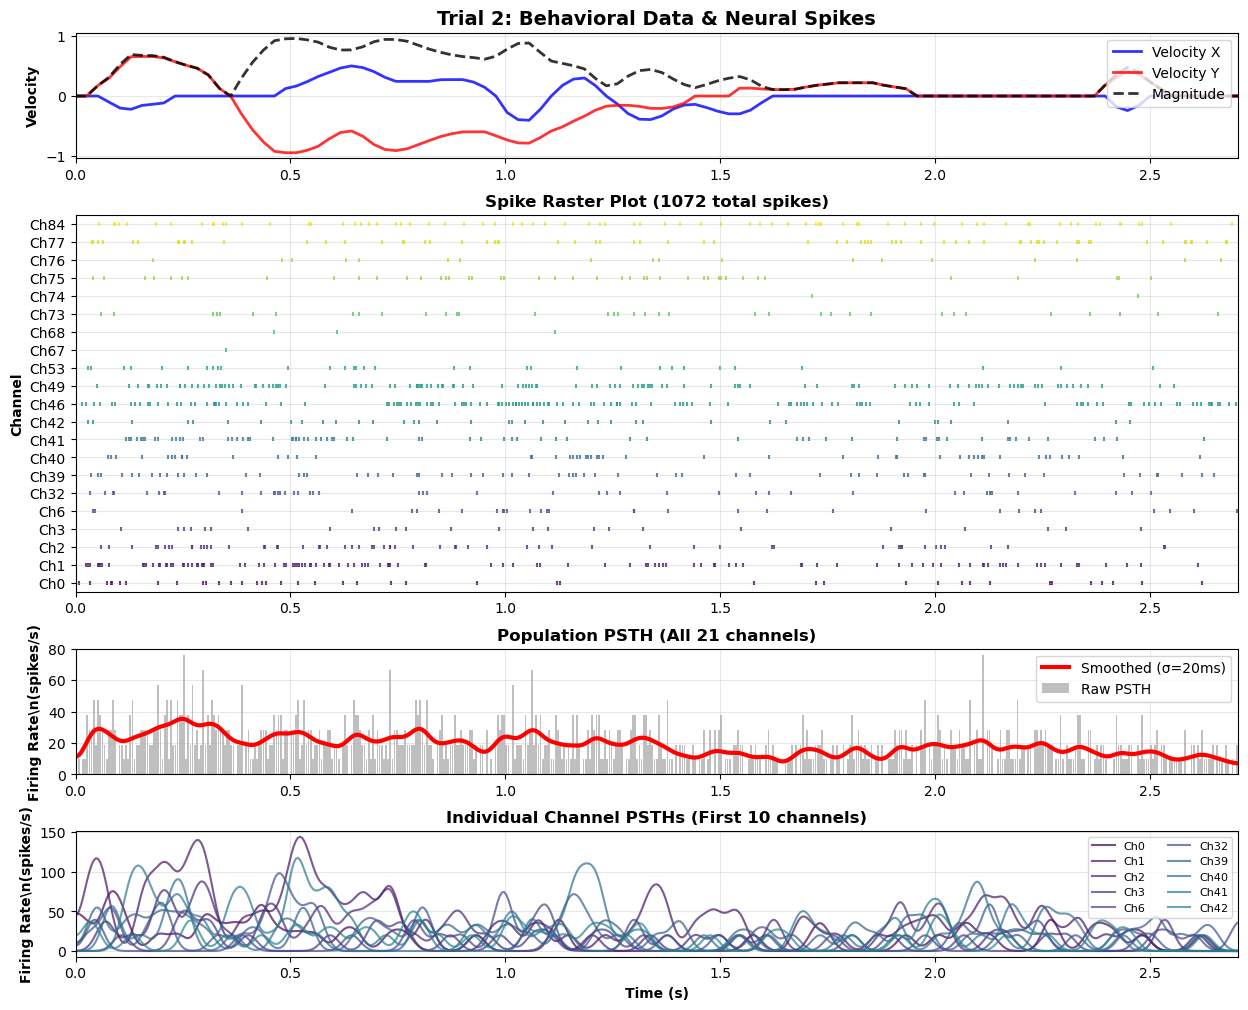


✅ Raster plot and PSTH generated successfully!
📊 Spike Detection Summary:
   • Total spikes detected: 1072
   • Active channels: 21/21
   • Average spikes per active channel: 51.0

📈 Top 10 most active channels:
    1. Channel 46: 139 spikes
    2. Channel 49: 118 spikes
    3. Channel  1: 111 spikes
    4. Channel 84:  75 spikes
    5. Channel 41:  71 spikes
    6. Channel 77:  69 spikes
    7. Channel 39:  63 spikes
    8. Channel  2:  59 spikes
    9. Channel 40:  51 spikes
   10. Channel 32:  45 spikes


In [8]:
from scipy.ndimage import gaussian_filter1d
from scipy import signal

def extract_spike_times(trial_data, features, channels=None):
    """
    Extract individual spike times from threshold crossings.
    
    Args:
        trial_data: Trial data dictionary
        features: Extracted features dictionary
        channels: List of channels to analyze (default: all spike channels)
    
    Returns:
        dict: Dictionary with spike times for each channel
    """
    if channels is None:
        channels = SPIKE_CHANNELS
    
    # Validate input data
    if trial_data is None:
        print("❌ No trial data provided")
        return {}
    
    if 'neural_data' not in trial_data or trial_data['neural_data'] is None:
        print("❌ No neural data found in trial_data")
        return {}
    
    # Get neural data and parameters
    neural_data = trial_data['neural_data']
    n_samples = neural_data.shape[1]
    
    # Calculate duration with fallback methods
    if 'duration' in trial_data and trial_data['duration'] is not None:
        duration = trial_data['duration']
    else:
        # Fallback: calculate duration from sampling rate
        duration = n_samples / SAMPLING_RATE
        print(f"⚠️  Duration not found in trial_data, calculated from samples: {duration:.2f}s")
    
    dt = duration / n_samples
    
    spike_times = {}
    
    print(f"🔍 Extracting spike times for {len(channels)} channels...")
    print(f"   • Neural data shape: {neural_data.shape}")
    print(f"   • Duration: {duration:.2f}s")
    print(f"   • Sampling rate: {SAMPLING_RATE} Hz")
    print(f"   • Time resolution: {dt*1000:.2f}ms")
    
    for i, channel in enumerate(channels):
        if channel >= neural_data.shape[0]:
            print(f"   ⚠️  Channel {channel} exceeds available channels ({neural_data.shape[0]})")
            continue
            
        # Get raw neural signal for this channel
        signal_data = neural_data[channel, :]
        
        # Apply bandpass filter for spike detection
        nyquist = SAMPLING_RATE / 2
        low = SPIKE_BAND_LOW / nyquist
        high = SPIKE_BAND_HIGH / nyquist
        
        try:
            b, a = signal.butter(SPIKE_FILTER_ORDER, [low, high], btype='band')
            filtered_signal = signal.filtfilt(b, a, signal_data)
        except:
            filtered_signal = signal_data
        
        # Calculate threshold
        if THRESHOLD_METHOD == 'rms':
            threshold = THRESHOLD_MULTIPLIER * np.sqrt(np.mean(filtered_signal**2))
        elif THRESHOLD_METHOD == 'std':
            threshold = THRESHOLD_MULTIPLIER * np.std(filtered_signal)
        elif THRESHOLD_METHOD == 'median':
            threshold = THRESHOLD_MULTIPLIER * np.median(np.abs(filtered_signal))
        else:  # manual
            threshold = MANUAL_THRESHOLD
        
        # Debug info for first few channels
        if i < 3:
            print(f"   • Channel {channel}: threshold = {threshold:.2f}μV ({THRESHOLD_METHOD} method)")
        
        # Find threshold crossings
        if THRESHOLD_POLARITY == 'negative':
            # Find negative-going crossings (signal goes from above to below threshold)
            crossings = np.where((filtered_signal[:-1] >= threshold) & (filtered_signal[1:] < threshold))[0]
        elif THRESHOLD_POLARITY == 'positive':
            # Find positive-going crossings (signal goes from below to above threshold)
            crossings = np.where((filtered_signal[:-1] <= threshold) & (filtered_signal[1:] > threshold))[0]
        else:  # both
            # Find all crossings (both directions)
            negative_crossings = np.where((filtered_signal[:-1] >= threshold) & (filtered_signal[1:] < threshold))[0]
            positive_crossings = np.where((filtered_signal[:-1] <= threshold) & (filtered_signal[1:] > threshold))[0]
            crossings = np.sort(np.concatenate([negative_crossings, positive_crossings]))
        
        # Apply refractory period
        if len(crossings) > 0:
            refractory_samples = int(MIN_SPIKE_INTERVAL * SAMPLING_RATE)
            filtered_crossings = [crossings[0]]
            
            for crossing in crossings[1:]:
                if crossing - filtered_crossings[-1] > refractory_samples:
                    filtered_crossings.append(crossing)
            
            # Convert to time
            spike_times[channel] = np.array(filtered_crossings) * dt
        else:
            spike_times[channel] = np.array([])
    
    # Summary statistics
    total_spikes = sum(len(spikes) for spikes in spike_times.values())
    active_channels = sum(1 for spikes in spike_times.values() if len(spikes) > 0)
    print(f"   ✅ Spike extraction complete:")
    print(f"      • Total spikes: {total_spikes}")
    print(f"      • Active channels: {active_channels}/{len(channels)}")
    
    return spike_times

def gaussian_smooth(data, sigma_ms, dt):
    """
    Apply Gaussian smoothing to data.
    
    Args:
        data: 1D array to smooth
        sigma_ms: Gaussian sigma in milliseconds
        dt: Time step in seconds
    
    Returns:
        Smoothed data
    """
    sigma_samples = (sigma_ms / 1000.0) / dt
    return gaussian_filter1d(data.astype(float), sigma=sigma_samples)

def plot_raster_and_psth(trial_data, features, channels=None, figsize=(15, 12), 
                        psth_bin_size=0.005, gaussian_sigma_ms=20):
    """
    Create comprehensive raster plot and PSTH with behavioral data.
    
    Args:
        trial_data: Trial data dictionary
        features: Extracted features dictionary
        channels: List of channels to plot (default: all spike channels)
        figsize: Figure size tuple
        psth_bin_size: Bin size for PSTH in seconds
        gaussian_sigma_ms: Gaussian smoothing kernel sigma in milliseconds
    """
    if channels is None:
        channels = SPIKE_CHANNELS
    
    # Validate input data
    if trial_data is None:
        print("❌ No trial data provided")
        return {}
    
    if 'neural_data' not in trial_data or trial_data['neural_data'] is None:
        print("❌ No neural data found in trial_data")
        return {}
    
    # Extract spike times
    spike_times = extract_spike_times(trial_data, features, channels)
    
    # Get trial duration with fallback methods
    if 'duration' in trial_data and trial_data['duration'] is not None:
        duration = trial_data['duration']
    else:
        # Fallback: calculate duration from neural data
        n_samples = trial_data['neural_data'].shape[1]
        duration = n_samples / SAMPLING_RATE
        print(f"⚠️  Duration not found in trial_data, calculated from samples: {duration:.2f}s")
    
    # Create figure with subplots
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(4, 1, height_ratios=[1, 3, 1, 1], hspace=0.3)
    
    # Colors for different channels
    colors = plt.cm.viridis(np.linspace(0, 1, len(channels)))
    
    # =================================================================
    # Top plot: Behavioral data
    # =================================================================
    ax_behavior = fig.add_subplot(gs[0])
    
    # Plot velocity data if available
    if 'velocity_x' in trial_data and trial_data['velocity_x'] is not None:
        velocity_x = trial_data['velocity_x']
        velocity_y = trial_data['velocity_y']
        
        # Create time axis for behavioral data
        if 'behavioral_timestamps' in trial_data and trial_data['behavioral_timestamps'] is not None:
            behavioral_timestamps = trial_data['behavioral_timestamps']
            behavioral_time = behavioral_timestamps - behavioral_timestamps[0]
        else:
            behavioral_time = np.linspace(0, duration, len(velocity_x))
        
        # Plot velocity components
        ax_behavior.plot(behavioral_time, velocity_x, 'b-', linewidth=2, label='Velocity X', alpha=0.8)
        ax_behavior.plot(behavioral_time, velocity_y, 'r-', linewidth=2, label='Velocity Y', alpha=0.8)
        
        # Plot velocity magnitude
        velocity_magnitude = np.sqrt(velocity_x**2 + velocity_y**2)
        ax_behavior.plot(behavioral_time, velocity_magnitude, 'k--', linewidth=2, 
                        label='Magnitude', alpha=0.8)
        
        ax_behavior.set_ylabel('Velocity', fontweight='bold')
        ax_behavior.legend(loc='upper right', fontsize=10)
        ax_behavior.set_title(f'Trial {TRIAL_NUMBER}: Behavioral Data & Neural Spikes', 
                             fontsize=14, fontweight='bold')
    else:
        ax_behavior.text(0.5, 0.5, 'No Behavioral Data Available', 
                        transform=ax_behavior.transAxes, ha='center', va='center',
                        fontsize=12, alpha=0.7)
        ax_behavior.set_title(f'Trial {TRIAL_NUMBER}: Neural Spike Raster & PSTH', 
                             fontsize=14, fontweight='bold')
    
    ax_behavior.set_xlim(0, duration)
    ax_behavior.grid(True, alpha=0.3)
    
    # =================================================================
    # Middle plot: Raster plot
    # =================================================================
    ax_raster = fig.add_subplot(gs[1])
    
    total_spikes = 0
    y_positions = []
    
    for i, channel in enumerate(channels):
        if channel in spike_times and len(spike_times[channel]) > 0:
            # Plot spikes for this channel
            y_pos = [i] * len(spike_times[channel])
            ax_raster.scatter(spike_times[channel], y_pos, 
                            c=[colors[i]], s=8, alpha=0.8, marker='|')
            total_spikes += len(spike_times[channel])
        
        y_positions.append(i)
    
    ax_raster.set_ylabel('Channel', fontweight='bold')
    ax_raster.set_xlim(0, duration)
    ax_raster.set_ylim(-0.5, len(channels) - 0.5)
    
    # Set y-axis labels to channel numbers
    ax_raster.set_yticks(y_positions)
    ax_raster.set_yticklabels([f'Ch{ch}' for ch in channels])
    
    ax_raster.set_title(f'Spike Raster Plot ({total_spikes} total spikes)', 
                       fontsize=12, fontweight='bold')
    ax_raster.grid(True, alpha=0.3)
    
    # =================================================================
    # Bottom plots: PSTH (Population and Individual)
    # =================================================================
    
    # Calculate PSTH
    time_bins = np.arange(0, duration + psth_bin_size, psth_bin_size)
    time_centers = time_bins[:-1] + psth_bin_size/2
    
    # Population PSTH
    ax_psth_pop = fig.add_subplot(gs[2])
    
    # Collect all spike times
    all_spikes = []
    for channel in channels:
        if channel in spike_times:
            all_spikes.extend(spike_times[channel])
    
    if len(all_spikes) > 0:
        # Create histogram
        psth_counts, _ = np.histogram(all_spikes, bins=time_bins)
        
        # Convert to firing rate (spikes/sec)
        psth_rate = psth_counts / (psth_bin_size * len(channels))
        
        # Apply Gaussian smoothing
        dt = psth_bin_size
        psth_smooth = gaussian_smooth(psth_rate, gaussian_sigma_ms, dt)
        
        # Plot raw PSTH
        ax_psth_pop.bar(time_centers, psth_rate, width=psth_bin_size*0.8, 
                       alpha=0.5, color='gray', label='Raw PSTH')
        
        # Plot smoothed PSTH
        ax_psth_pop.plot(time_centers, psth_smooth, 'r-', linewidth=3, 
                        label=f'Smoothed (σ={gaussian_sigma_ms}ms)')
        
        ax_psth_pop.set_ylabel('Firing Rate\\n(spikes/s)', fontweight='bold')
        ax_psth_pop.legend(loc='upper right', fontsize=10)
        ax_psth_pop.set_title(f'Population PSTH (All {len(channels)} channels)', 
                             fontsize=12, fontweight='bold')
        
        # Print statistics
        print(f"📊 PSTH Statistics:")
        print(f"   • Total spikes: {len(all_spikes)}")
        print(f"   • Mean firing rate: {np.mean(psth_rate):.2f} spikes/s")
        print(f"   • Peak firing rate: {np.max(psth_smooth):.2f} spikes/s")
        print(f"   • Smoothing kernel: {gaussian_sigma_ms}ms Gaussian")
    
    else:
        ax_psth_pop.text(0.5, 0.5, 'No Spikes Detected', 
                        transform=ax_psth_pop.transAxes, ha='center', va='center',
                        fontsize=12, alpha=0.7)
        ax_psth_pop.set_title('Population PSTH (No spikes detected)', 
                             fontsize=12, fontweight='bold')
    
    ax_psth_pop.set_xlim(0, duration)
    ax_psth_pop.grid(True, alpha=0.3)
    
    # Channel-wise PSTH
    ax_psth_chan = fig.add_subplot(gs[3])
    
    # Plot individual channel PSTHs
    for i, channel in enumerate(channels[:10]):  # Limit to first 10 channels for clarity
        if channel in spike_times and len(spike_times[channel]) > 0:
            # Create histogram for this channel
            channel_counts, _ = np.histogram(spike_times[channel], bins=time_bins)
            channel_rate = channel_counts / psth_bin_size
            
            # Apply Gaussian smoothing
            channel_smooth = gaussian_smooth(channel_rate, gaussian_sigma_ms, dt)
            
            # Plot smoothed PSTH
            ax_psth_chan.plot(time_centers, channel_smooth, 
                             color=colors[i], linewidth=1.5, alpha=0.7,
                             label=f'Ch{channel}')
    
    ax_psth_chan.set_xlabel('Time (s)', fontweight='bold')
    ax_psth_chan.set_ylabel('Firing Rate\\n(spikes/s)', fontweight='bold')
    ax_psth_chan.set_xlim(0, duration)
    ax_psth_chan.set_title(f'Individual Channel PSTHs (First 10 channels)', 
                          fontsize=12, fontweight='bold')
    ax_psth_chan.legend(loc='upper right', fontsize=8, ncol=2)
    ax_psth_chan.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return spike_times

# Generate the raster plot and PSTH
if trial_data is not None and features is not None:
    print("🎯 Generating Raster Plot and PSTH...")
    spike_times = plot_raster_and_psth(trial_data, features, 
                                      channels=SPIKE_CHANNELS, 
                                      figsize=(15, 12),
                                      psth_bin_size=0.005,  # 5ms bins
                                      gaussian_sigma_ms=20)  # 20ms Gaussian kernel
    
    print(f"\n✅ Raster plot and PSTH generated successfully!")
    print(f"📊 Spike Detection Summary:")
    total_spikes = sum(len(spikes) for spikes in spike_times.values())
    active_channels = sum(1 for spikes in spike_times.values() if len(spikes) > 0)
    print(f"   • Total spikes detected: {total_spikes}")
    print(f"   • Active channels: {active_channels}/{len(SPIKE_CHANNELS)}")
    print(f"   • Average spikes per active channel: {total_spikes/max(1, active_channels):.1f}")
    
    # Channel-wise spike counts
    print(f"\n📈 Top 10 most active channels:")
    channel_counts = [(ch, len(spike_times.get(ch, []))) for ch in SPIKE_CHANNELS]
    channel_counts.sort(key=lambda x: x[1], reverse=True)
    
    for i, (ch, count) in enumerate(channel_counts[:10]):
        if count > 0:
            print(f"   {i+1:2d}. Channel {ch:2d}: {count:3d} spikes")
    
else:
    print("❌ Cannot generate raster plot - no trial data or features available")


📚 Utility functions loaded!
Available functions:
  • save_features(features, filename)
  • load_saved_features(filename)
  • explore_different_trial(trial_number)
  • quick_channel_comparison(features, [ch1, ch2, ch3])
  • explore_channel(features, channel_number)

🔍 Comparing channels 74, 41, and 46:


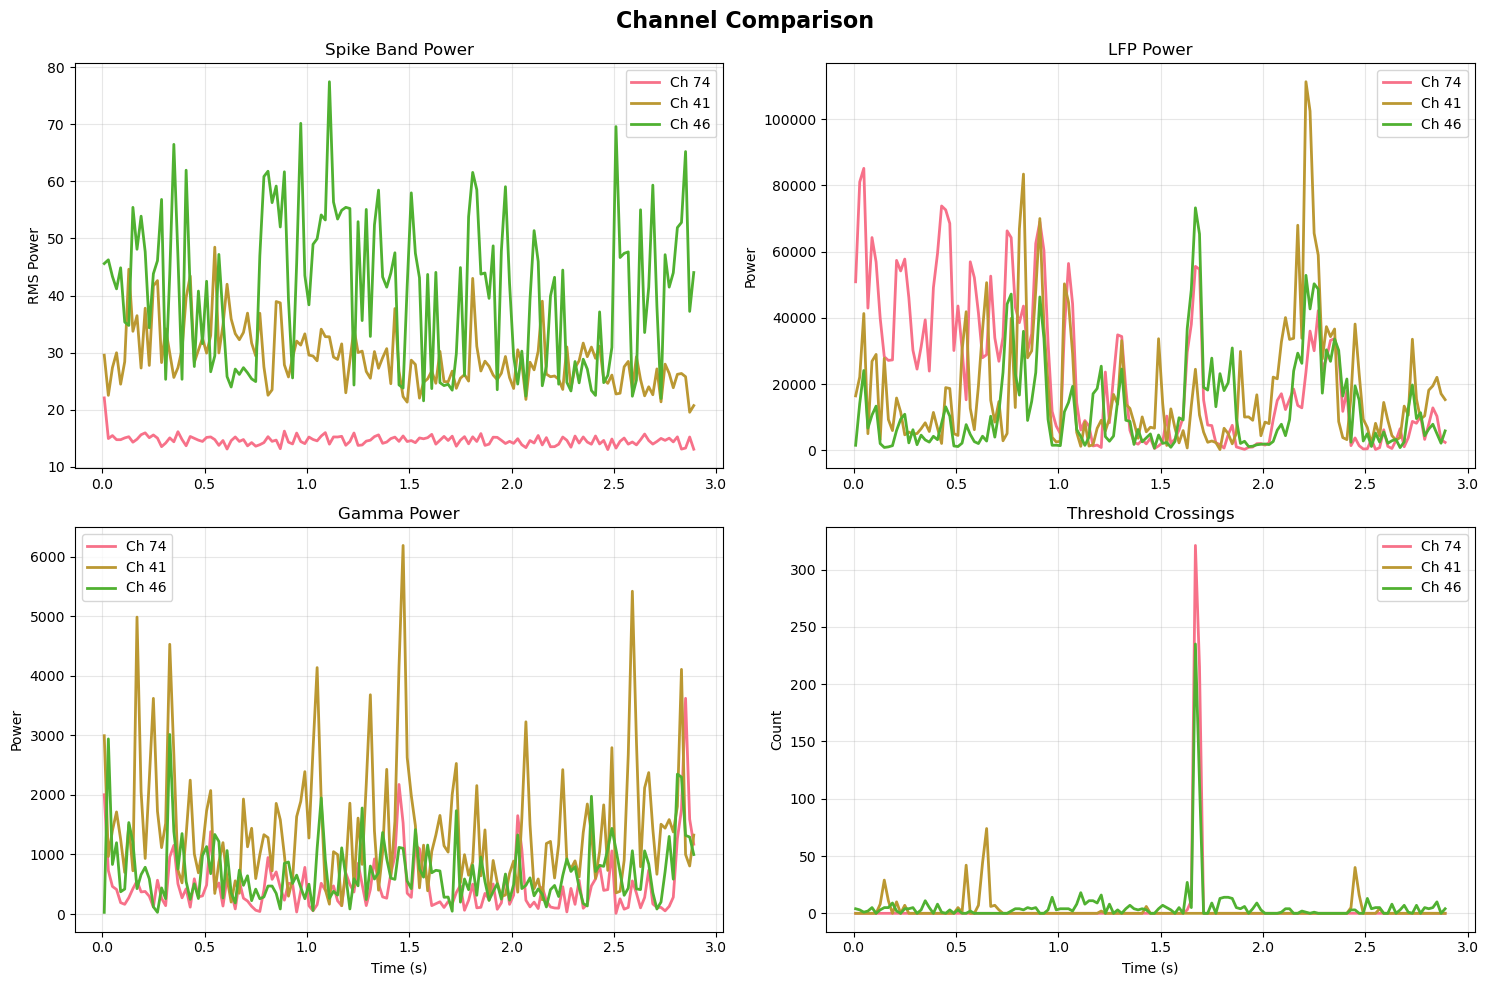

In [9]:
def save_features(features, filename=None):
    """Save extracted features to a NumPy file."""
    if features is None:
        print("❌ No features to save")
        return
    
    if filename is None:
        filename = f'neural_features_trial_{TRIAL_NUMBER:03d}.npz'
    
    np.savez_compressed(filename, **features)
    print(f"💾 Features saved to {filename}")

def load_saved_features(filename):
    """Load previously saved features."""
    try:
        loaded_features = np.load(filename, allow_pickle=True)
        
        # Convert back to dictionary format
        features_dict = {}
        for key in loaded_features.files:
            features_dict[key] = loaded_features[key].item() if loaded_features[key].ndim == 0 else loaded_features[key]
        
        print(f"📂 Loaded features from {filename}")
        return features_dict
    except FileNotFoundError:
        print(f"❌ File {filename} not found")
        return None

def explore_different_trial(trial_number):
    """Load and explore features from a different trial."""
    global TRIAL_NUMBER
    old_trial = TRIAL_NUMBER
    TRIAL_NUMBER = trial_number
    
    trial_data, features = load_and_extract_features(trial_number)
    
    if features is not None:
        print(f"\n🔍 Exploring Trial {trial_number}:")
        show_feature_summary(features)
        quick_plot_features(features)
    
    TRIAL_NUMBER = old_trial  # Reset to original
    return trial_data, features

def quick_channel_comparison(features, channels_to_compare):
    """Compare specific channels side by side."""
    if features is None:
        print("❌ No features to compare")
        return
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Channel Comparison', fontsize=16, fontweight='bold')
    
    time_axis = features['spike_band']['time_axis']
    
    for i, ch in enumerate(channels_to_compare):
        if ch not in SPIKE_CHANNELS:
            continue
            
        ch_idx = SPIKE_CHANNELS.index(ch)
        
        # Spike power
        axes[0, 0].plot(time_axis, features['spike_band']['rms_power'][ch_idx], 
                       label=f'Ch {ch}', linewidth=2)
        
        # LFP power  
        axes[0, 1].plot(time_axis, features['lfp']['lfp_power'][ch_idx], 
                       label=f'Ch {ch}', linewidth=2)
        
        # Gamma power
        axes[1, 0].plot(time_axis, features['lfp']['gamma_power'][ch_idx], 
                       label=f'Ch {ch}', linewidth=2)
        
        # Threshold crossings
        axes[1, 1].plot(time_axis, features['threshold']['crossing_counts'][ch_idx], 
                       label=f'Ch {ch}', linewidth=2)
    
    # Set titles and labels
    axes[0, 0].set_title('Spike Band Power')
    axes[0, 0].set_ylabel('RMS Power')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    axes[0, 1].set_title('LFP Power')
    axes[0, 1].set_ylabel('Power')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    axes[1, 0].set_title('Gamma Power')
    axes[1, 0].set_xlabel('Time (s)')
    axes[1, 0].set_ylabel('Power')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    axes[1, 1].set_title('Threshold Crossings')
    axes[1, 1].set_xlabel('Time (s)')
    axes[1, 1].set_ylabel('Count')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Example usage
print("📚 Utility functions loaded!")
print("Available functions:")
print("  • save_features(features, filename)")
print("  • load_saved_features(filename)")
print("  • explore_different_trial(trial_number)")
print("  • quick_channel_comparison(features, [ch1, ch2, ch3])")
print("  • explore_channel(features, channel_number)")

# Example: Compare a few interesting channels
if features is not None:
    print("\n🔍 Comparing channels 74, 41, and 46:")
    quick_channel_comparison(features, [74, 41, 46])


🎨 Creating synchronized visualization for trial 2...
📊 Available keys in trial_data: ['neural_data', 'trial_number', 'velocity_x', 'velocity_y', 'behavioral_timestamps', 'duration', 'end_seconds', 'end_time', 'outcome', 'start_seconds', 'start_time', 'target_index']
📊 Data types: [('neural_data', <class 'numpy.ndarray'>), ('velocity_x', <class 'numpy.ndarray'>), ('velocity_y', <class 'numpy.ndarray'>), ('behavioral_timestamps', <class 'numpy.ndarray'>)]
📊 Data shapes:
   Neural data: (96, 87168)
   Velocity X: (106,)
   Velocity Y: (106,)
🧠 Selected neural channels: [33 42 69 73 77 79 80 94]
⏱️  Neural time range: 0 to 2.71 seconds
🕹️  Behavioral time range: 0 to 2.71 seconds


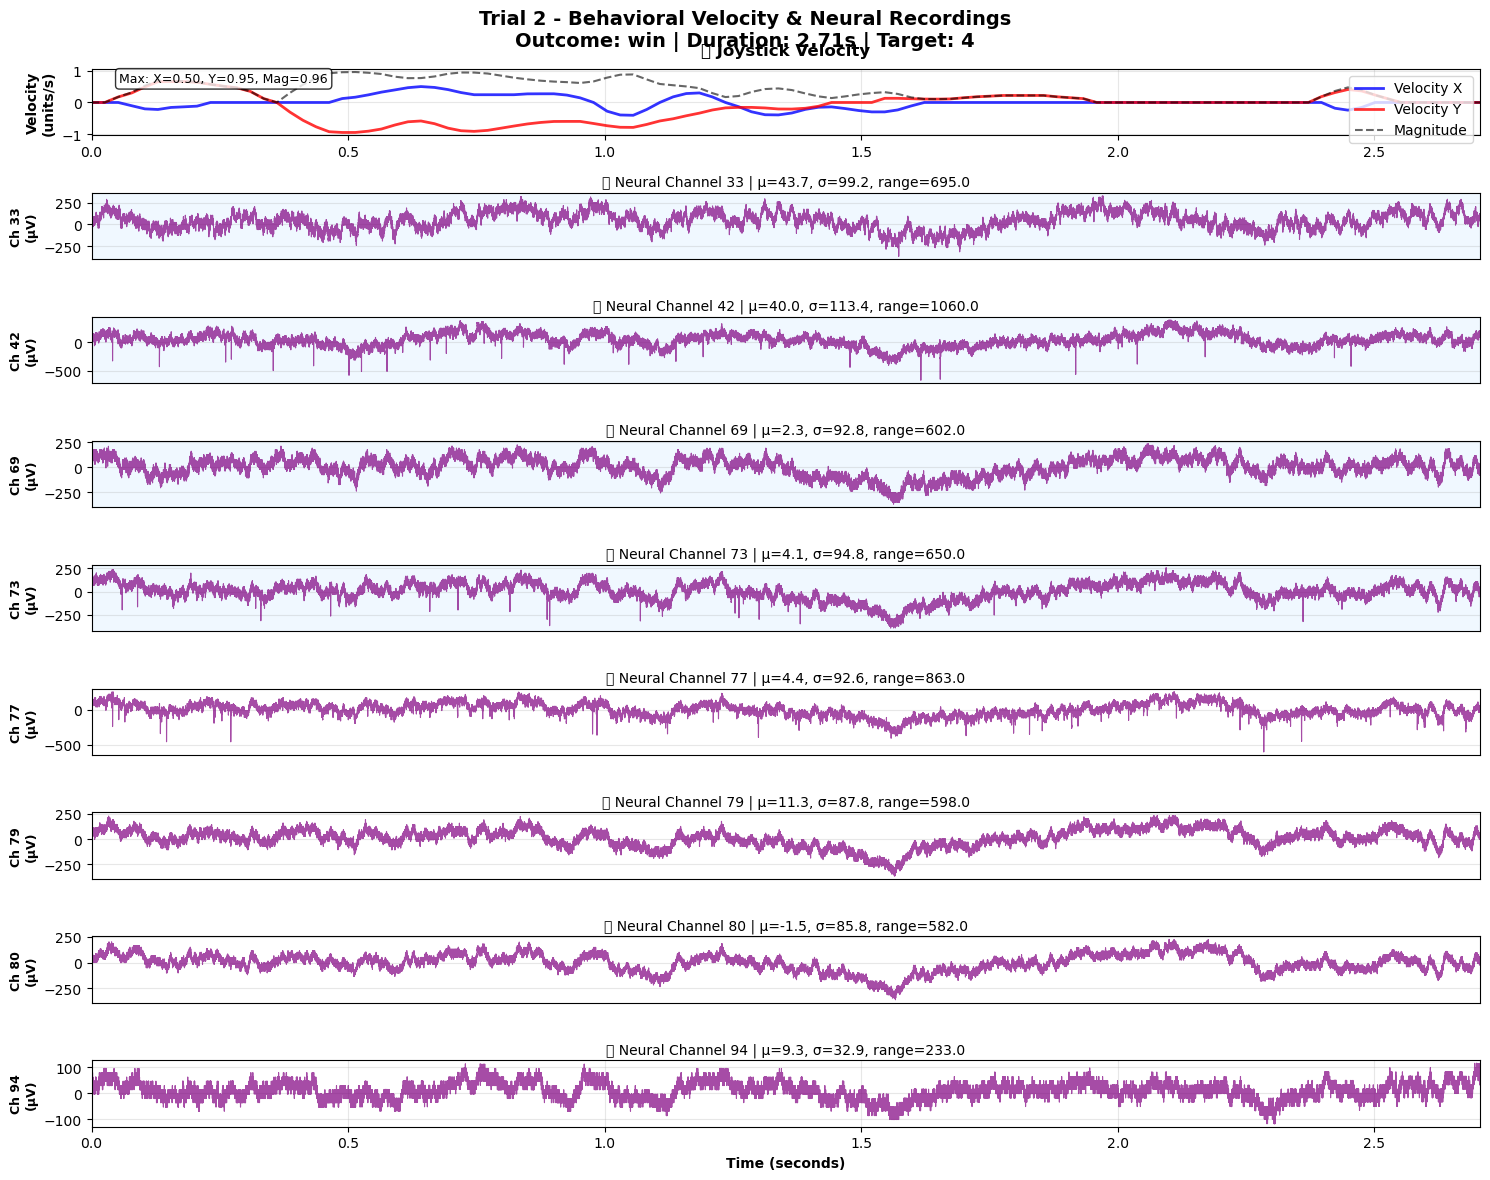


📊 Trial 2 Summary Statistics:
   🕹️  Behavioral:
      Velocity X: mean=0.003, std=0.189
      Velocity Y: mean=-0.135, std=0.424
      Peak magnitude: 0.964
   🧠 Neural (selected channels):
      Ch 33: mean=  43.7, std= 99.2, range= 695.0
      Ch 42: mean=  40.0, std=113.4, range=1060.0
      Ch 69: mean=   2.3, std= 92.8, range= 602.0
      Ch 73: mean=   4.1, std= 94.8, range= 650.0
      Ch 77: mean=   4.4, std= 92.6, range= 863.0
      Ch 79: mean=  11.3, std= 87.8, range= 598.0
      Ch 80: mean=  -1.5, std= 85.8, range= 582.0
      Ch 94: mean=   9.3, std= 32.9, range= 233.0

⚡ Data Quality Indicators:
   Neural-Behavioral time alignment: ✅ Good
   Neural data variability: ✅ Good
   Behavioral activity detected: ✅ Yes


In [10]:
# Create synchronized visualization of behavioral velocity and neural recordings
print(f"🎨 Creating synchronized visualization for trial {TRIAL_NUMBER}...")

# Debug: Check what keys are available in trial_data
print(f"📊 Available keys in trial_data: {list(trial_data.keys())}")
print(f"📊 Data types: {[(k, type(v)) for k, v in trial_data.items() if isinstance(v, (np.ndarray, type(None)))]}")

# Prepare neural data
neural_data = trial_data.get('neural_data', None)
velocity_x = trial_data.get('velocity_x', None)
velocity_y = trial_data.get('velocity_y', None)
behavioral_timestamps = trial_data.get('behavioral_timestamps', None)

# Check if we have the required data
if neural_data is None:
    print("❌ No neural data found for this trial!")
    neural_data = np.zeros((96, 1000))  # Create dummy data
    
if velocity_x is None or velocity_y is None:
    print("❌ No behavioral velocity data found for this trial!")
    print("Available data keys:", [k for k, v in trial_data.items() if isinstance(v, np.ndarray)])
    # Create dummy velocity data
    velocity_x = np.zeros(100)
    velocity_y = np.zeros(100)
    behavioral_timestamps = None

print(f"📊 Data shapes:")
print(f"   Neural data: {neural_data.shape}")
print(f"   Velocity X: {velocity_x.shape if velocity_x is not None else 'None'}")
print(f"   Velocity Y: {velocity_y.shape if velocity_y is not None else 'None'}")

# Create time axes
neural_samples = neural_data.shape[1]
neural_time = np.linspace(0, trial_data['duration'], neural_samples)

# Convert behavioral timestamps to relative time
if behavioral_timestamps is not None and len(behavioral_timestamps) > 0:
    behavioral_time = behavioral_timestamps - behavioral_timestamps[0]
else:
    # If no timestamps, assume uniform spacing
    behavioral_time = np.linspace(0, trial_data['duration'], len(velocity_x))

# Select 8 random channels for visualization
np.random.seed(42)  # For reproducible results
n_channels_to_plot = min(8, neural_data.shape[0])
selected_channels = np.random.choice(neural_data.shape[0], n_channels_to_plot, replace=False)
selected_channels = np.sort(selected_channels)

print(f"🧠 Selected neural channels: {selected_channels}")
print(f"⏱️  Neural time range: 0 to {neural_time[-1]:.2f} seconds")
print(f"🕹️  Behavioral time range: 0 to {behavioral_time[-1]:.2f} seconds")

# Create the visualization
fig, axes = plt.subplots(n_channels_to_plot + 1, 1, figsize=(15, 12))
fig.suptitle(f'Trial {TRIAL_NUMBER} - Behavioral Velocity & Neural Recordings\n'
             f'Outcome: {trial_data["outcome"]} | Duration: {trial_data["duration"]:.2f}s | '
             f'Target: {trial_data.get("target_index", "N/A")}', 
             fontsize=14, fontweight='bold')

# Plot behavioral velocity (top subplot)
ax_behavior = axes[0]

# Plot velocity components
ax_behavior.plot(behavioral_time, velocity_x, 'b-', linewidth=2, label='Velocity X', alpha=0.8)
ax_behavior.plot(behavioral_time, velocity_y, 'r-', linewidth=2, label='Velocity Y', alpha=0.8)

# Calculate and plot velocity magnitude
velocity_magnitude = np.sqrt(velocity_x**2 + velocity_y**2)
ax_behavior.plot(behavioral_time, velocity_magnitude, 'k--', linewidth=1.5, 
                label='Magnitude', alpha=0.6)

ax_behavior.set_ylabel('Velocity\n(units/s)', fontweight='bold')
ax_behavior.set_title('🕹️ Joystick Velocity', fontweight='bold', pad=10)
ax_behavior.legend(loc='upper right')
ax_behavior.grid(True, alpha=0.3)
ax_behavior.set_xlim(0, max(neural_time[-1], behavioral_time[-1]))

# Add velocity statistics
vel_stats = f'Max: X={np.max(np.abs(velocity_x)):.2f}, Y={np.max(np.abs(velocity_y)):.2f}, Mag={np.max(velocity_magnitude):.2f}'
ax_behavior.text(0.02, 0.95, vel_stats, transform=ax_behavior.transAxes, 
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
                fontsize=9, verticalalignment='top')

# Plot neural recordings (remaining subplots)
for i, channel_idx in enumerate(selected_channels):
    ax = axes[i + 1]
    
    # Get neural signal for this channel
    neural_signal = neural_data[channel_idx, :]
    
    # Plot neural signal
    ax.plot(neural_time, neural_signal, 'purple', linewidth=0.8, alpha=0.7)
    
    # Add channel info and statistics
    signal_mean = np.mean(neural_signal)
    signal_std = np.std(neural_signal)
    signal_range = np.max(neural_signal) - np.min(neural_signal)
    
    ax.set_ylabel(f'Ch {channel_idx}\n(μV)', fontweight='bold', fontsize=9)
    ax.set_title(f'🧠 Neural Channel {channel_idx} | μ={signal_mean:.1f}, σ={signal_std:.1f}, range={signal_range:.1f}', 
                fontsize=10, pad=5)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, max(neural_time[-1], behavioral_time[-1]))
    
    # Color-code based on activity level
    if signal_std > np.median([np.std(neural_data[ch, :]) for ch in selected_channels]):
        ax.patch.set_facecolor('#f0f8ff')  # Light blue for high activity
    
    # Only show x-axis label on bottom subplot
    if i == len(selected_channels) - 1:
        ax.set_xlabel('Time (seconds)', fontweight='bold')
    else:
        ax.set_xticks([])

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()

# Print summary statistics
print(f"\n📊 Trial {TRIAL_NUMBER} Summary Statistics:")
print(f"   🕹️  Behavioral:")
if velocity_x is not None and velocity_y is not None:
    print(f"      Velocity X: mean={np.mean(velocity_x):.3f}, std={np.std(velocity_x):.3f}")
    print(f"      Velocity Y: mean={np.mean(velocity_y):.3f}, std={np.std(velocity_y):.3f}")
    print(f"      Peak magnitude: {np.max(velocity_magnitude):.3f}")
    behavioral_activity = np.max(velocity_magnitude)
else:
    print(f"      No behavioral data available")
    behavioral_activity = 0

print(f"   🧠 Neural (selected channels):")
for ch in selected_channels:
    signal = neural_data[ch, :]
    print(f"      Ch {ch:2d}: mean={np.mean(signal):6.1f}, std={np.std(signal):5.1f}, range={np.ptp(signal):6.1f}")

print(f"\n⚡ Data Quality Indicators:")
time_alignment_good = abs(neural_time[-1] - behavioral_time[-1]) < 1.0 if len(behavioral_time) > 0 else False
print(f"   Neural-Behavioral time alignment: {'✅ Good' if time_alignment_good else '⚠️ Check needed'}")
print(f"   Neural data variability: {'✅ Good' if np.std(neural_data) > 0.1 else '⚠️ Low variance'}")
print(f"   Behavioral activity detected: {'✅ Yes' if behavioral_activity > 0.1 else '⚠️ Low activity'}")